### Imports

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr


import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData



In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Data loading

In [3]:
"""
Load the footprints for the region and period with the base data object.
Stores the footprints (without cropping) in data.fp_data_full
load_everything=True also loads the original meteorology, without cropping or interpolating, in data.met_file, as well as the topography and landuse in data.topog_file and data.landcover_file, which are interpolated in space to the shape of the footprints
"""
data = LoadBaseSatelliteData(201601, region="BRAZIL", load_everything=True, verbose=True)

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201601*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 1438 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201601*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


## Plotting meteorology

In [12]:
data.met_file

<xarray.Dataset> Size: 26GB
Dimensions:                              (levels: 20, lat: 357, lon: 239,
                                          time: 744)
Coordinates:
  * lat                                  (lat) float64 3kB -60.98 ... 22.32
    sigma                                (levels) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
  * levels                               (levels) int32 80B 1 3 6 9 ... 51 54 57
    level_height                         (levels) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
  * lon                                  (lon) float64 2kB -91.33 ... -7.553
  * time                                 (time) datetime64[ns] 6kB 2016-01-01...
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 5GB dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 254MB dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 5GB dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 254MB dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 254MB dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 254MB dask.array<chunksize=(357, 239, 500), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 5GB dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 5GB dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 5GB dask.array<chunksize=(20, 357, 239, 500), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

## Plotting footprints

In [14]:
data.fp_data_full

<xarray.Dataset> Size: 516MB
Dimensions:               (time: 1438, lon: 190, lat: 357, lev: 1, height: 20)
Coordinates:
  * time                  (time) datetime64[ns] 12kB 2016-01-01T14:59:12.5000...
  * lon                   (lon) float32 760B -91.33 -90.98 ... -25.15 -24.8
  * lat                   (lat) float32 1kB -60.98 -60.75 -60.51 ... 22.09 22.32
  * lev                   (lev) |S1 1B b'c'
  * height                (height) float32 80B 500.0 1.5e+03 ... 1.95e+04
Data variables:
    fp                    (lat, lon, time) float32 390MB dask.array<chunksize=(72, 38, 25), meta=np.ndarray>
    temperature           (time) float32 6kB dask.array<chunksize=(25,), meta=np.ndarray>
    pressure              (time) float32 6kB dask.array<chunksize=(25,), meta=np.ndarray>
    wind_speed            (time) float32 6kB dask.array<chunksize=(25,), meta=np.ndarray>
    wind_direction        (time) float32 6kB dask.array<chunksize=(25,), meta=np.ndarray>
    PBLH                  (time) float32 6kB dask.array<chunksize=(25,), meta=np.ndarray>
    release_lon           (time) float32 6kB dask.array<chunksize=(25,), meta=np.ndarray>
    release_lat           (time) float32 6kB dask.array<chunksize=(25,), meta=np.ndarray>
    particle_locations_n  (height, lon, time) float32 22MB dask.array<chunksize=(10, 95, 25), meta=np.ndarray>
    particle_locations_e  (height, lat, time) float32 41MB dask.array<chunksize=(7, 119, 25), meta=np.ndarray>
    particle_locations_s  (height, lon, time) float32 22MB dask.array<chunksize=(10, 95, 25), meta=np.ndarray>
    particle_locations_w  (height, lat, time) float32 41MB dask.array<chunksize=(7, 119, 25), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-29 20:05:49.874413

## Plotting topography and land use

In [13]:
data.topog_file

<xarray.Dataset> Size: 274kB
Dimensions:             (lat: 357, lon: 190)
Coordinates:
  * lat                 (lat) float32 1kB -60.98 -60.75 -60.51 ... 22.09 22.32
  * lon                 (lon) float32 760B -91.33 -90.98 -90.62 ... -25.15 -24.8
Data variables:
    surface_altitude    (lat, lon) float32 271kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    latitude_longitude  int32 4B -2147483647
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   8.3
    Conventions:  CF-1.7

In [76]:
data.landcover_file

<xarray.Dataset>
Dimensions:             (pseudo_level: 9, lat: 357, lon: 190)
Coordinates:
  * pseudo_level        (pseudo_level) int32 1 2 3 4 5 6 7 8 9
  * lat                 (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lon                 (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
Data variables:
    landcover_fraction  (lat, lon, pseudo_level) float32 nan nan nan ... nan nan
    land_binary_mask    (lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    landcover_type      (lat, lon) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    source:      Data from Met Office Unified Model
    um_version:  8.3
    STASH:       [  1   0 216]

## Jeff trying stuff out

### Plot map with bounding box for data

In [59]:
def get_lat_lon_bounds(data, type = "met"):
    """Return a dictionary with the min/max lat/lon bounds from the specified data series (met, fp, or topo)."""
    if type == "met":
        lat_met = data.met_file["lat"].values
        lon_met = data.met_file["lon"].values
    elif type == "fp":
        lat_met = data.fp_data_full["lat"].values
        lon_met = data.fp_data_full["lon"].values
    elif type == "topo":
        lat_met = data.topog_file["lat"].values
        lon_met = data.topog_file["lon"].values
    return dict(
        min_lat=float(np.min(lat_met)),
        max_lat=float(np.max(lat_met)),
        min_lon=float(np.min(lon_met)),
        max_lon=float(np.max(lon_met)),
    )

def rectangle_segments(min_lon, max_lon, min_lat, max_lat, wrap_center=0):
    """
    Return 1 or 2 polygons (lon, lat) for a rectangle, splitting if it crosses the anti-meridian.
    """
    # To cover case where min_lon > max_lon due to anti-meridian crossing (ie near New Zealand / Alaska), we split into two segments
    if max_lon < min_lon:
        segA = [
            (min_lon, min_lat), (wrap_center+180, min_lat),
            (wrap_center+180, max_lat), (min_lon, max_lat)
        ]
        segB = [
            (wrap_center-180, min_lat), (max_lon, min_lat),
            (max_lon, max_lat), (wrap_center-180, max_lat)
        ]
        return [segA, segB]
    else:
        return [[(min_lon, min_lat), (max_lon, min_lat), (max_lon, max_lat), (min_lon, max_lat)]]

def add_lonlat_rectangle(ax, min_lon, max_lon, min_lat, max_lat,
                         edgecolor='tab:blue', facecolor='none', linewidth=2.2,
                         zorder=5, wrap_center=0, crs=ccrs.PlateCarree(), label=None):
    polys = rectangle_segments(min_lon, max_lon, min_lat, max_lat, wrap_center=wrap_center)
    first = True
    for poly in polys:
        patch = Polygon(np.array(poly), closed=True,
                        edgecolor=edgecolor, facecolor=facecolor, linewidth=linewidth,
                        zorder=zorder, transform=crs,
                        label=label if first and label else None)
        ax.add_patch(patch)
        first = False

def plot_domain(data, type, 
                  projection="PlateCarree",  # "PlateCarree" or "Robinson" etc.
                  wrap_center=0,
                  zoom_to_data=True,
                  title="UM Meteorology Domain"):
    """Plot the bounding rectangle from the provided `data` container."""
    # 1) Get bounds from helper
    met_bounds = get_lat_lon_bounds(data, type)

    # 2) Choose projection
    proj_map = {
        "PlateCarree": ccrs.PlateCarree(),
        "Robinson": ccrs.Robinson(),
        "Mollweide": ccrs.Mollweide(),
        "Mercator": ccrs.Mercator(),
        "LambertConformal": ccrs.LambertConformal(),
    }.get(projection, ccrs.PlateCarree())

    # 3) Base map
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj_map)
    ax.set_global()
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')

    # 4) Draw the Met rectangle
    add_lonlat_rectangle(ax,
                         met_bounds["min_lon"], met_bounds["max_lon"],
                         met_bounds["min_lat"], met_bounds["max_lat"],
                         edgecolor='tab:blue', linewidth=2.2, label=f'{type} domain',
                         wrap_center=wrap_center)

    # 5) Legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc='lower left', frameon=True)

    # 6) Optional zoom to Met extent (only if it doesn't cross anti-meridian near NZ)
    if zoom_to_data:
        min_lon, max_lon = met_bounds["min_lon"], met_bounds["max_lon"]
        min_lat, max_lat = met_bounds["min_lat"], met_bounds["max_lat"]
        if max_lon >= min_lon:  # no anti-meridian crossing
            ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    plt.title(title, pad=10)
    plt.tight_layout()
    return fig, ax

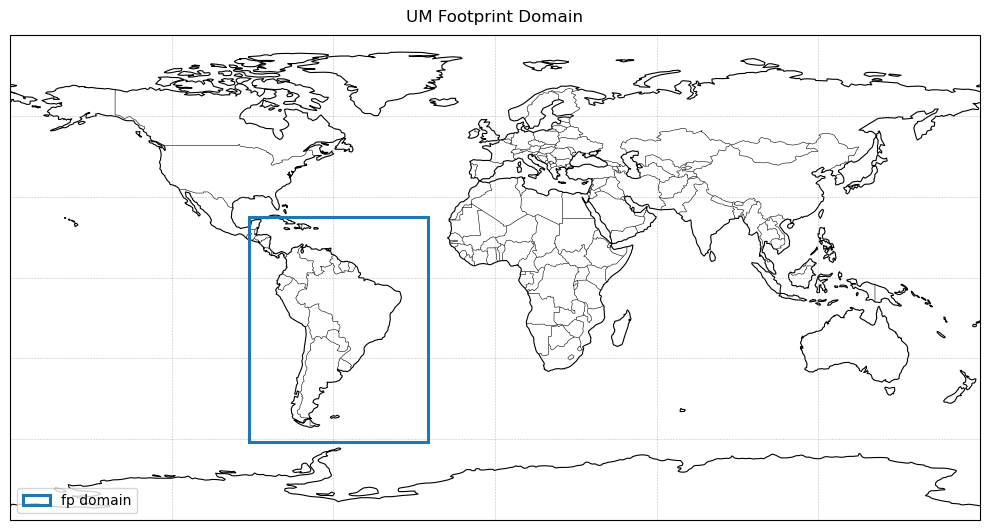

In [60]:
fig, ax = plot_domain(
    data, "fp",
    projection="PlateCarree",  # "PlateCarree" gives a true lon/lat view; "Robinson" for global context
    zoom_to_data=False,
    title="UM Footprint Domain"
)
plt.show()

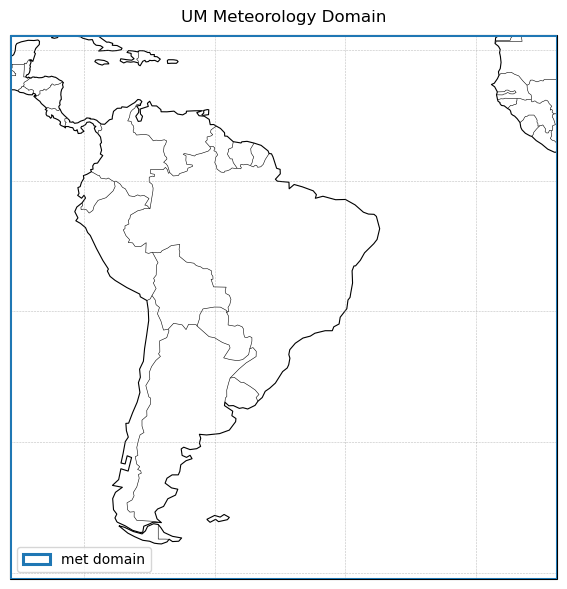

In [63]:
# Can also constrain to only showing the met domain
fig, ax = plot_domain(
    data, "met",
    projection="PlateCarree",  # "PlateCarree" gives a true lon/lat view; "Robinson" for global context
    zoom_to_data=True,
    title="UM Meteorology Domain"
)
plt.show()

In [15]:
## Extensions to add:
# 1. Plotting met and fp rectangles on the same map, with different colours and a legend
# 2. Plotting multiple domains together (eg Sahara and Brazil)

### Plot topo

In [57]:
def plot_topography(data,
                    cmap='terrain',
                    plot_country_boundaries=False,
                    add_contours=False,
                    contour_interval=None,       # e.g. 250 or 500 (m); if None matplotlib chooses ~20 levels

        ):
    """ Use the topography data in `data.topog_file` to create a map of surface altitude. 
    
    Parameters
    ----------
    data: LoadBaseSatelliteData
        The data container with the topography dataset loaded in `data.topog_file`.
    cmap: str, optional
        The colormap to use for the topography. Default is 'terrain'.
    plot_country_boundaries: bool, optional
        Whether to overlay country boundaries on the map. Default is False.
    add_contours: bool, optional
        Whether to add contour lines to emphasize relief. Default is False.
    contour_interval : float | None
        Interval in meters for contours. If None and add_contours=True,
        uses ~20 automatically chosen levels.
    
    """

    ds = data.topog_file
    da = ds['surface_altitude']  # (lat, lon)

    # Optional: clean up or mask unrealistic values
    # Example: clip altitudes to a practical range and mask fill values
    da = da.where(np.isfinite(da))
    Z = da.values

    # If attrs has units set keep, otherwise assume meters
    units = da.attrs.get('units', 'm')
    long_name = da.attrs.get('long_name', 'Surface altitude')

    lon = ds['lon'].values
    lat = ds['lat'].values


    # Create figure
    fig = plt.figure(figsize=(10.5, 5))
    proj = ccrs.PlateCarree()
    ax = plt.axes(projection=proj)



    # Add features: coastine and country borders
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, linewidth=0.3, color='0.5', alpha=0.6)

    if plot_country_boundaries:
        ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="black", alpha=0.7)

    # Use pcolormesh; xarray will broadcast lat/lon correctly if passed in order (lon, lat)
    mesh = ax.pcolormesh(
        lon, lat, da.values,
        transform=proj,
        cmap=cmap,
        shading='auto'  # avoids gridline artifacts
    )

    # Optional: add a thin contour overlay to emphasize relief
    #cs = ax.contour(lon, lat, da.values, transform=proj, levels=20, colors='k', linewidths=0.2, alpha=0.5)

        # --- Optional contours ---
    if add_contours:
        if contour_interval is not None:
            zmin = np.nanmin(Z)
            zmax = np.nanmax(Z)
            start = np.floor(zmin / contour_interval) * contour_interval
            stop  = np.ceil(zmax / contour_interval) * contour_interval
            levels = np.arange(start, stop + contour_interval, contour_interval)
        else:
            levels = 20  # let matplotlib choose ~20 evenly spaced levels
        cs = ax.contour(
            lon, lat, Z,
            levels=levels,
            colors='k',
            linewidths=0.4,
            alpha=0.6,
            transform=proj
        )
        # Label every ~1000 m if using fixed interval
        if contour_interval:
            idx_levels = np.arange(
                np.ceil(np.nanmin(Z) / 1000) * 1000,
                np.floor(np.nanmax(Z) / 1000) * 1000 + 1,
                1000
            )
            try:
                cs_idx = ax.contour(
                    lon, lat, Z,
                    levels=idx_levels,
                    colors='k',
                    linewidths=0.6,
                    alpha=0.7,
                    transform=proj
                )
                ax.clabel(cs_idx, fmt='%1.0f', inline=True, fontsize=7)
            except Exception:
                pass



    # Colorbar
    cb = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.06, shrink=0.85)
    cb.set_label(f"{long_name} [{units}]")

    # Title
    plt.title(long_name if long_name else 'Topography')
    plt.tight_layout()
    plt.show()
    return fig, ax

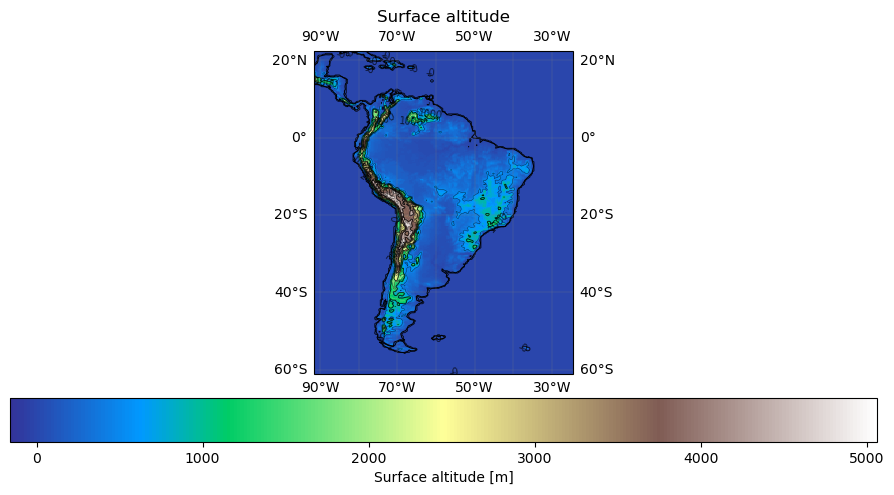

In [58]:
fig, ax = plot_topography(
    data,
    plot_country_boundaries=False,
    add_contours=True,
    contour_interval=500
)
plt.show()

### Land-use

In [75]:
# Work in progress!

data.landcover_file

<xarray.Dataset>
Dimensions:             (pseudo_level: 9, lat: 357, lon: 190)
Coordinates:
  * pseudo_level        (pseudo_level) int32 1 2 3 4 5 6 7 8 9
  * lat                 (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lon                 (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
Data variables:
    landcover_fraction  (lat, lon, pseudo_level) float32 nan nan nan ... nan nan
    land_binary_mask    (lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    landcover_type      (lat, lon) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    source:      Data from Met Office Unified Model
    um_version:  8.3
    STASH:       [  1   0 216]

In [65]:
data.landcover_file["landcover_type"]

<xarray.DataArray 'landcover_type' (lat: 357, lon: 190)>
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * lat      (lat) float32 -60.98 -60.75 -60.51 -60.28 ... 21.85 22.09 22.32
  * lon      (lon) float32 -91.33 -90.98 -90.62 -90.27 ... -25.5 -25.15 -24.8

In [73]:
def plot_landuse_frequency(
        data,
        outfile=None
        ):
    """
    Plot a simple bar chart showing the total fractional area for each land-use class

    Parameters
    ----------
    landcover_fraction_da : xarray.DataArray
        DataArray with dims (lat, lon, pseudo_level) OR (pseudo_level, lat, lon)
    outfile : str or None
        If provided, saves the figure to this filepath

    Returns
    -------
    fig, ax : Matplotlib figure and axes
    freq : np.ndarray
        Total fractional area per pseudo-level
    """


    da = data.landcover_file['landcover_fraction']

    # Ensure dimension ordering (lat, lon, pseudo_level)
    if da.dims == ('pseudo_level', 'lat', 'lon'):
        da = da.transpose('lat', 'lon', 'pseudo_level')
    elif da.dims != ('lat', 'lon', 'pseudo_level'):
        raise ValueError(f"Unexpected dims {da.dims}. Expected (lat, lon, pseudo_level).")

    # Sum fractional area for each pseudo-level class
    freq = da.sum(dim=('lat', 'lon')).values  # shape (n_classes,)
    class_ids = da['pseudo_level'].values     # typically 1..9

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(class_ids, freq, color='steelblue', edgecolor='black')

    ax.set_title("Land-use frequency (sum of fractions per class)")
    ax.set_xlabel("Pseudo-level (land-use class index)")
    ax.set_ylabel("Total fractional area")

    ax.set_xticks(class_ids)
    plt.tight_layout()

    # Save if requested
    if outfile:
        plt.savefig(outfile, bbox_inches='tight')
        print(f"Saved land-use bar chart to: {outfile}")

    plt.show()

    return fig, ax, freq

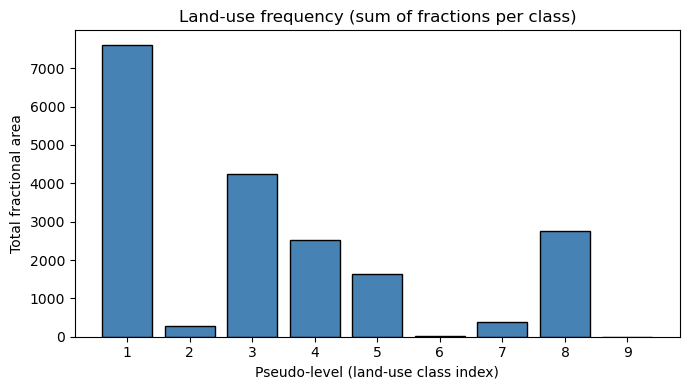

In [74]:
fig, ax, freq = plot_landuse_frequency(data,
                                       #outfile="landuse_frequency.png"   # optional; omit to only display
                                       )